# VIVA Q&A


Q1: What is the main purpose of the Logistic curve?
Answer: It is used to model things that grow very fast at first, but eventually slow down and stop at a maximum limit (an "S-shape").

Q2: What is the exact formula used in your code?
Answer: y = c / (1 + a * exp(-b * t)).

Q3: What do the parameters 'a', 'b', and 'c' represent?
Answer: * c: The "carrying capacity" or the maximum ceiling the growth can reach.

b: The growth rate (how fast it grows).

a: A shift parameter that controls where the curve starts.

Q4: In your code, why did you use y_data.max() as the initial guess for 'c'?
Answer: Because 'c' represents the absolute maximum ceiling of the curve. The highest actual value in our data is the most logical starting guess for that ceiling.

Q5: What is the biggest difference between the Logistic curve and the Gompertz curve?
Answer: The Logistic curve is perfectly symmetric (the start of the curve mirrors the end). The Gompertz curve is asymmetric (it shoots up fast but takes a long time to flatten out).

Q6: Why is the microbial dataset perfect for this practical?
Answer: Because bacteria in a petri dish grow rapidly until they run out of food and space, at which point the population flatlines. This perfectly creates the Logistic "S-shape".

Q7: What does the optimization engine (curve_fit) actually do?
Answer: It uses trial and error to test thousands of numbers until it finds the perfect values for 'a', 'b', and 'c' that make the curve trace our real data with the lowest possible error.

Q8: Why don't you need to convert dates to numbers in this practical?
Answer: Because the microbial dataset provides time in pure numerical hours (0, 1, 2, 3...). The computer can already do math on these numbers, so date conversion is unnecessary.

--- Practical 3: Logistic Curve Fitting ---
Loading dataset...

Calculating Initial Guesses for Parameters (a, b, c)...
Initial Guesses -> a: 4.54, b: 0.50, c: 0.7090

Fitting the Logistic curve to the data...
Optimized values for best fit: a = 10.5968, b = 0.0519, c = 8.0127e-01

Covariance matrix of the parameters (a, b, c):
[[ 3.36450202e-02  8.93843403e-05 -4.01861950e-04]
 [ 8.93843403e-05  4.76677035e-07 -4.16753385e-06]
 [-4.01861950e-04 -4.16753385e-06  4.79455635e-05]]

Coefficient of Determination (R^2 Score) = 0.9896


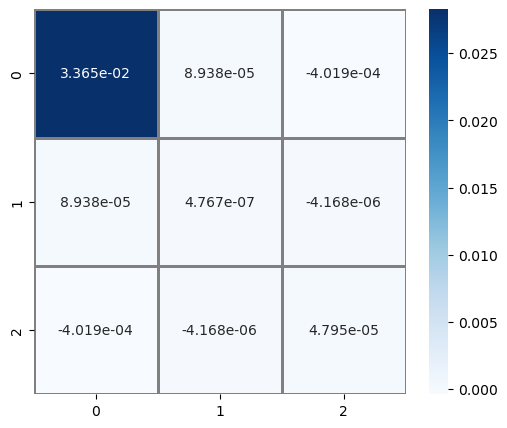

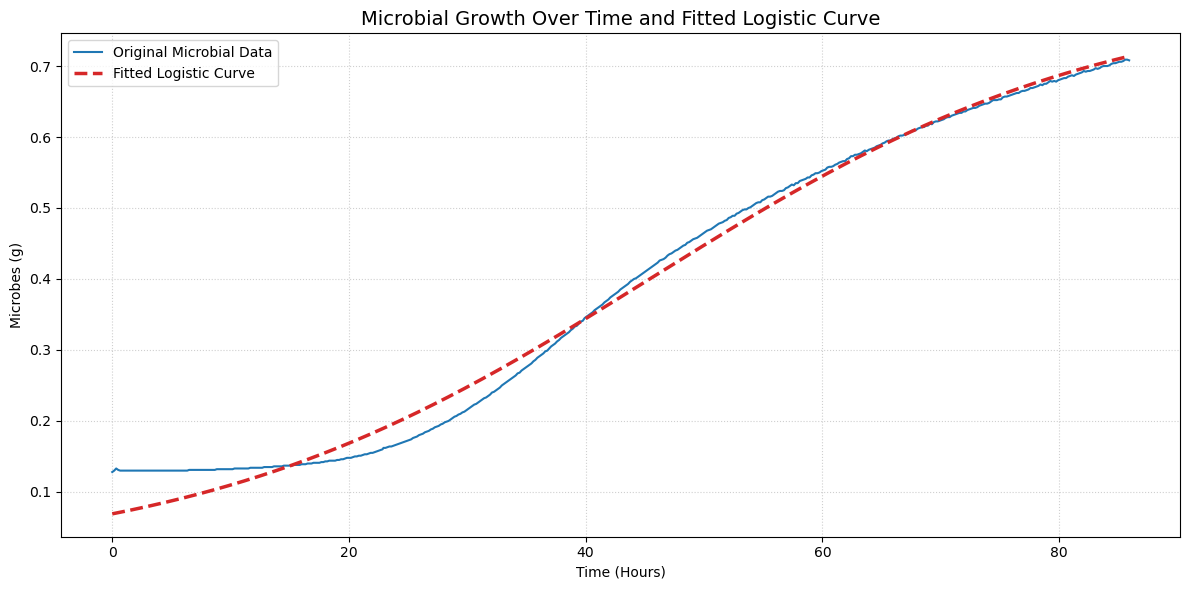

In [19]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

def fit_logistic_curve():
    print("--- Practical 3: Logistic Curve Fitting ---")
    
    # 1. Load the Microbial Dataset
    path = r"C:\Users\Mahesh Khairnar\Time Series Analysis and Forecasting\Practical Datasets\microbial_growth_curve.csv"
    print("Loading dataset...")
    df = pd.read_csv(path)

    # Sort values to ensure chronological order
    df.sort_values('t [h]', inplace=True)
    
    # Extract numerical time (hours) and the microbial population
    x_numerical = df['t [h]']
    y_data = df['microbes(g)']

    # 2. Define the Logistic Model
    # The mathematical formula is: y = c / (1 + a * e^(-bt))
    def logistic_curve_fun(t,a,b,c):
        return c / (1 + a*np.exp(-b*t))

    print("\nCalculating Initial Guesses for Parameters (a, b, c)...")
    
    # 'c' is the maximum carrying capacity (the ceiling)
    c_guess = y_data.max()
    
    # 'a' shifts the curve. We can estimate it using the formula: a = (c - y0) / y0
    y_start = y_data.iloc[0]
    a_guess = (c_guess - y_start)/y_start    
    # 'b' is the growth rate. 0.5 is a standard, safe starting guess for bacteria
    b_guess = 0.5
    
    print(f"Initial Guesses -> a: {a_guess:.2f}, b: {b_guess:.2f}, c: {c_guess:.4f}")

    print("\nFitting the Logistic curve to the data...")
    p0 = (a_guess, b_guess, c_guess)
    
    # Run the non-linear optimization
    popt, pcov = curve_fit(logistic_curve_fun, x_numerical, y_data, p0=p0, maxfev=10000)
    
    print(f"Optimized values for best fit: a = {popt[0]:.4f}, b = {popt[1]:.4f}, c = {popt[2]:.4e}")
    print("\nCovariance matrix of the parameters (a, b, c):")
    print(pcov)

    # 3. Plot the Covariance Matrix Heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(pcov,cmap="Blues",annot=True,fmt='.3e',linestyle="--",linewidths=1,linecolor="gray",robust=True)

    # 4. Generate the trend line and R-Squared Score
    y_pred = logistic_curve_fun(x_numerical, *popt)
    r_squared = r2_score(y_data, y_pred)
    print(f"\nCoefficient of Determination (R^2 Score) = {r_squared:.4f}")

    # 5. Plot the Original Data vs Logistic Curve
    plt.figure(figsize=(12, 6))
    
    # Raw Data
    plt.plot(x_numerical, y_data, label='Original Microbial Data', color='tab:blue')
    # Fitted Logistic Curve
    plt.plot(x_numerical, y_pred, '--', label='Fitted Logistic Curve', color='tab:red', linewidth=2.5)
    
    plt.title('Microbial Growth Over Time and Fitted Logistic Curve',fontsize=14)
    plt.xlabel('Time (Hours)')
    plt.ylabel('Microbes (g)')
    plt.legend(loc='best')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    fit_logistic_curve()